In [8]:
#script to compare old and new Item Parameter computation (for ELA, run on the same data)

tablename = 'ELAITEMPARAMETERESTIMATES20241212'
file1 = 'model_v50_sigmoidRegressorXGB/ELA_ItemParameters_v3_continuous.csv'
file2 = 'model_v50_sigmoidRegressorXGB/ELA_ItemParameters_v5.csv'
filename = file2

File 1 shape: (105816, 19)
File 2 shape: (136899, 19)
Merged dataframe shape: (100849, 36)
Column: discriminability
  Number of significant differences: 63375
  Max difference: 99.0
  Difference range: -99.0 to 99.0
Column: difficulty
  Number of significant differences: 38926
  Max difference: 3.606605740643716
  Difference range: -3.497493862051482 to 3.606605740643716
Column: guessing
  Number of significant differences: 27249
  Max difference: 0.5
  Difference range: -0.5 to 0.4999999999999999
Column: inattention
  Number of significant differences: 10005
  Max difference: 0.5
  Difference range: -0.5 to 0.4999999999999999
Column: discriminability_error
  Number of significant differences: 77893
  Max difference: 204452103284.44156
  Difference range: -24.352345586811335 to 26.043599571233816
Column: difficulty_error
  Number of significant differences: 15447
  Max difference: 2333027723.0119658
  Difference range: -21.570432713332142 to 20.30579034901824
Column: guessing_error
  N

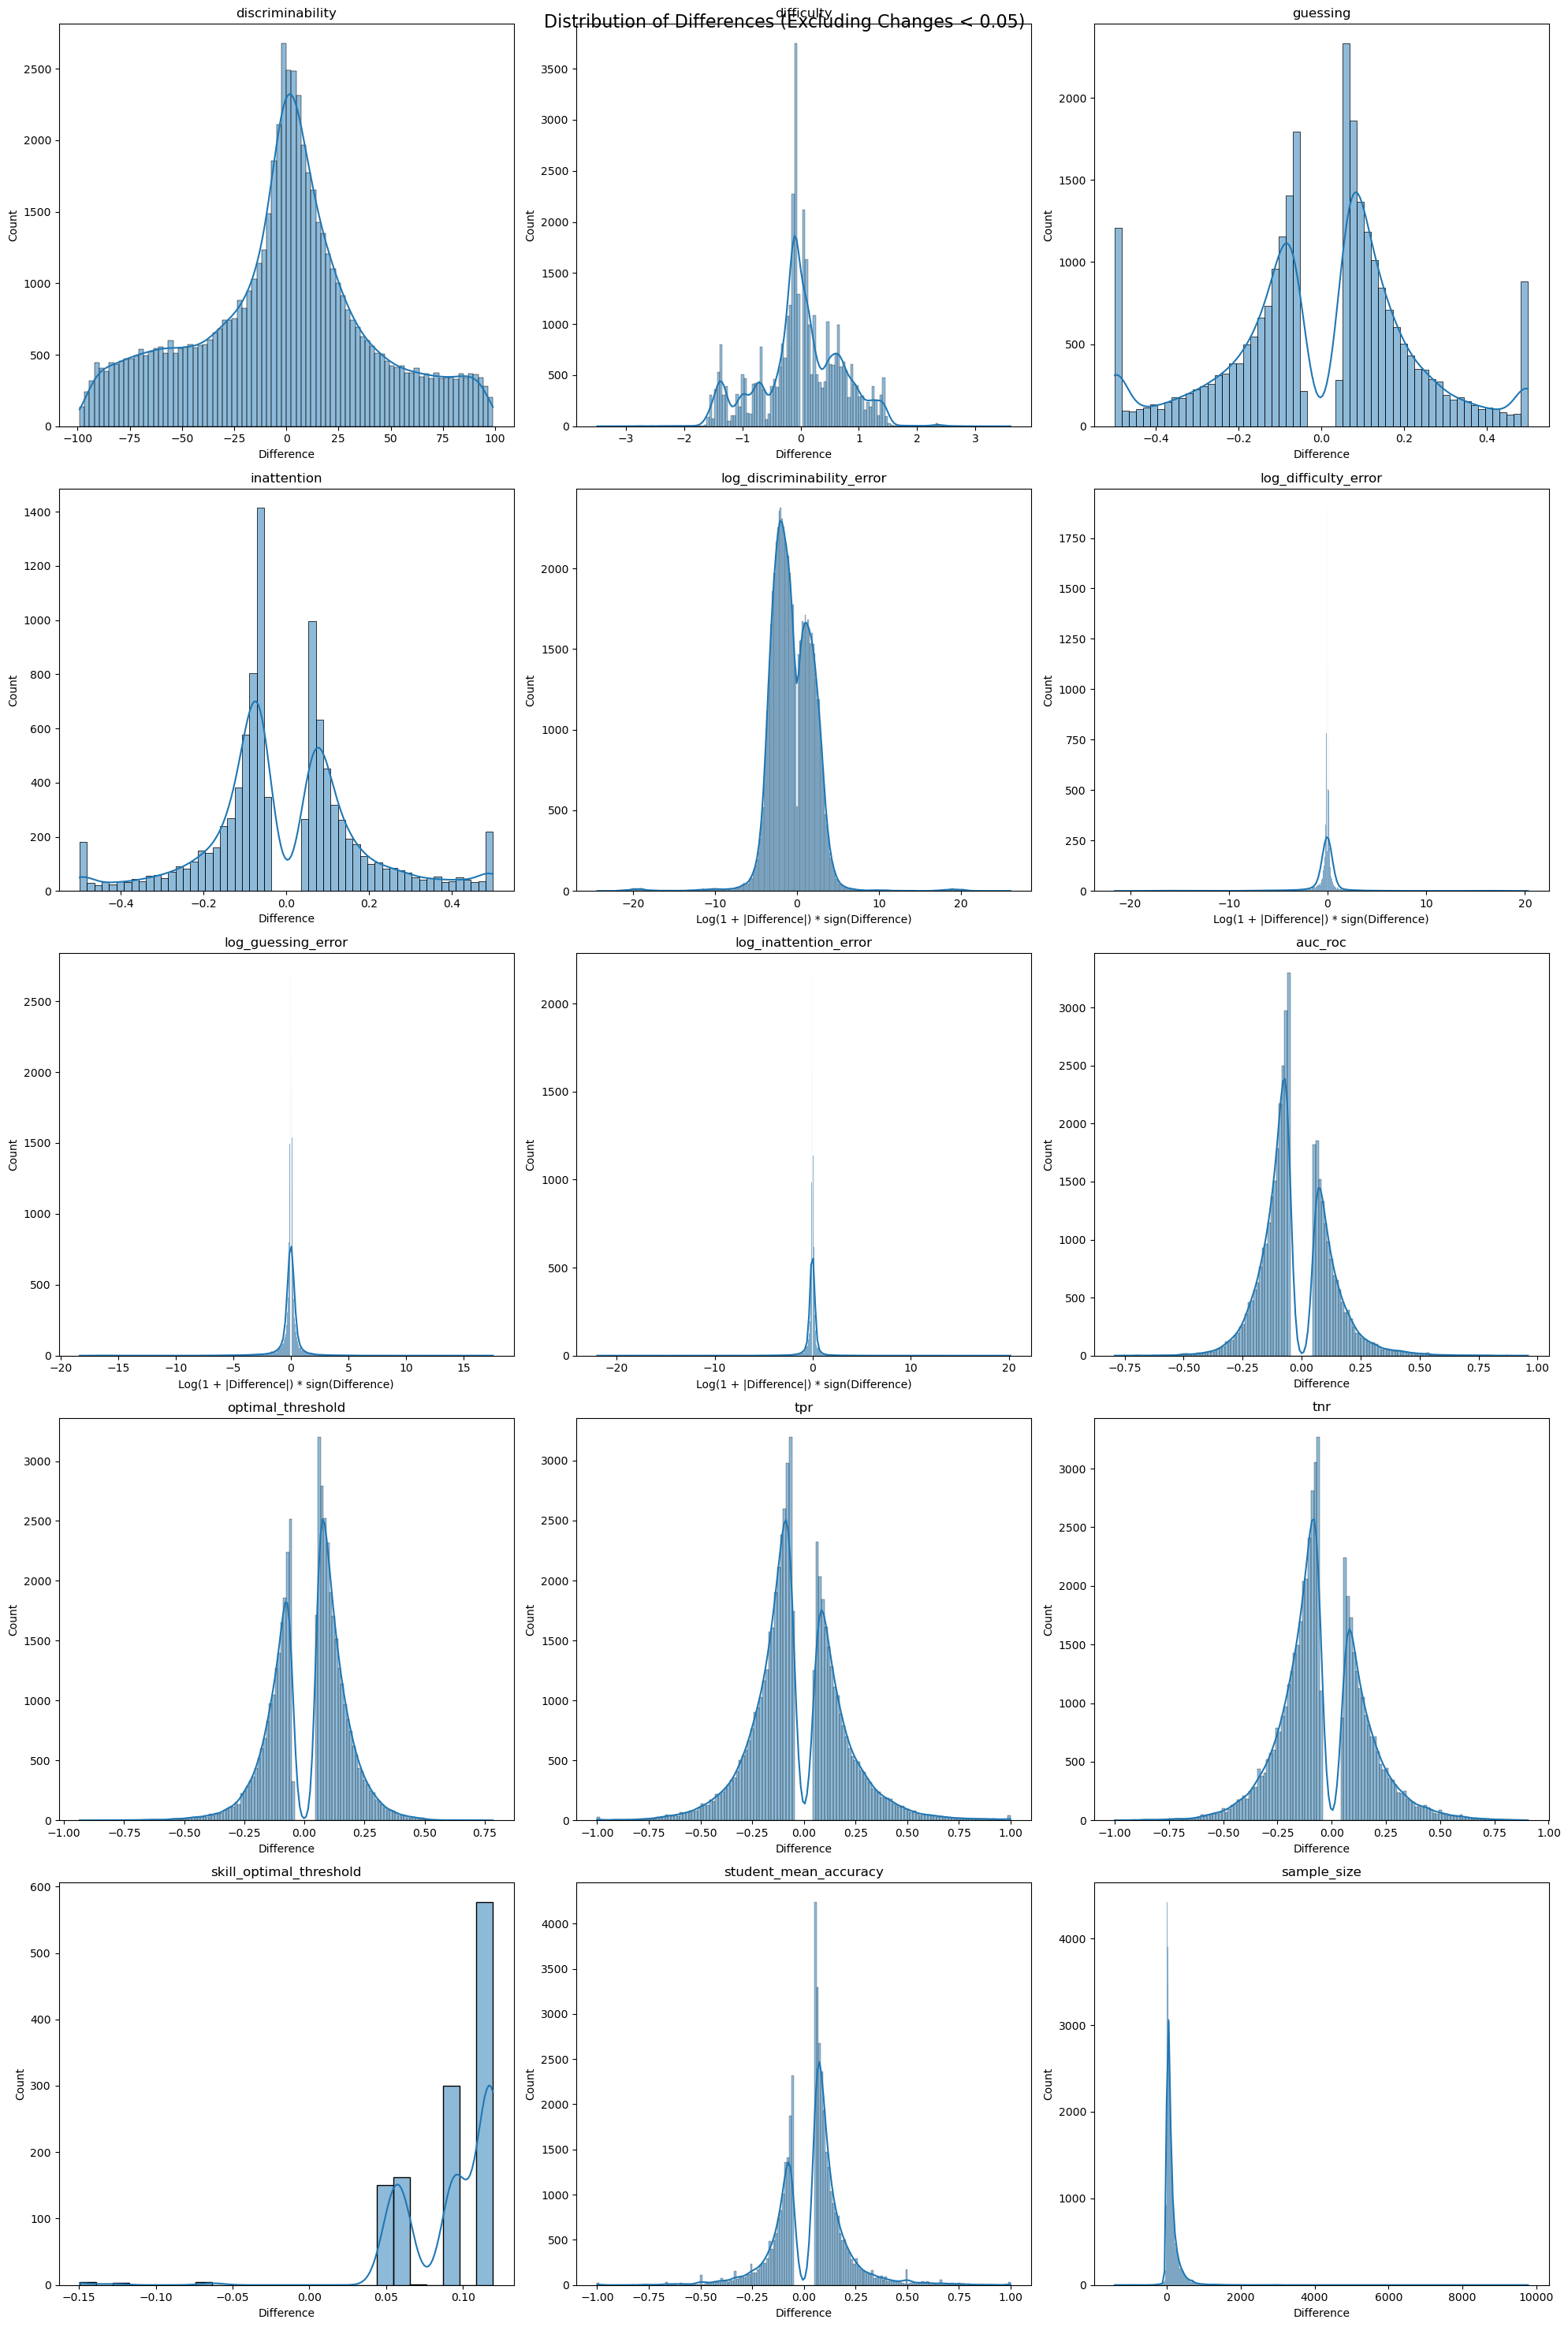


Summary:
1) Missing or extra skill_ids:
   Missing: 25
   Extra: 275

2) Missing or extra question_ids:
   Missing: 1403
   Extra: 19309

3) Number of extra or less empty IRT param columns:
   discriminability: -4658
   difficulty: -16104
   guessing: -4658
   inattention: -4658

4) Number of extra or less empty SDT param columns:
   auc_roc: -4914
   optimal_threshold: -4914
   tpr: -4914
   tnr: -4914
   skill_optimal_threshold: -12417

5) Max significant differences:
   discriminability: 99.0
   difficulty: 3.606605740643716
   guessing: 0.5
   inattention: 0.5
   discriminability_error: 204452103284.44156
   difficulty_error: 2333027723.0119658
   guessing_error: 94035791.32369778
   inattention_error: 3536832665.869706
   auc_roc: 0.9595201884483884
   optimal_threshold: 0.9346591530821476
   tpr: 1.0000000000000002
   tnr: 1.0
   skill_optimal_threshold: 0.1496152955721719
   student_mean_accuracy: 1.0
   sample_size: 9774


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the tolerance for differences
TOLERANCE = 0.05

# Read CSV files
# file1 = 'ELA_ItemParameters_3monthsv12.csv'
df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

print(f"File 1 shape: {df1.shape}")
print(f"File 2 shape: {df2.shape}")

# 1) Compare skill_ids
skill_ids1 = set(df1['skill_id'])
skill_ids2 = set(df2['skill_id'])
missing_skill_ids = len(skill_ids1 - skill_ids2)
extra_skill_ids = len(skill_ids2 - skill_ids1)

# 2) Compare question_ids
question_ids1 = set(df1['question_id'])
question_ids2 = set(df2['question_id'])
missing_question_ids = len(question_ids1 - question_ids2)
extra_question_ids = len(question_ids2 - question_ids1)

# 3) Compare empty cells in IRT params
irt_params = ['discriminability', 'difficulty', 'guessing', 'inattention']
irt_empty_diff = {}
for param in irt_params:
    empty1 = df1[param].isna().sum()
    empty2 = df2[param].isna().sum()
    irt_empty_diff[param] = empty2 - empty1

# 4) Compare empty cells in SDT params
sdt_params = ['auc_roc', 'optimal_threshold', 'tpr', 'tnr', 'skill_optimal_threshold']
sdt_empty_diff = {}
for param in sdt_params:
    empty1 = df1[param].isna().sum()
    empty2 = df2[param].isna().sum()
    sdt_empty_diff[param] = empty2 - empty1

# 5) Calculate max differences and create distribution plots
diff_columns = ['discriminability', 'difficulty', 'guessing', 'inattention',
                'discriminability_error', 'difficulty_error', 'guessing_error', 'inattention_error',
                'auc_roc', 'optimal_threshold', 'tpr', 'tnr', 'skill_optimal_threshold',
                'student_mean_accuracy', 'sample_size']

max_diffs = {}
diff_data = {}

merged = pd.merge(df1, df2, on=['question_id', 'skill_id'], suffixes=('_1', '_2'))
print(f"Merged dataframe shape: {merged.shape}")

for col in diff_columns:
    col1 = f"{col}_1"
    col2 = f"{col}_2"
    
    if col1 not in merged.columns or col2 not in merged.columns:
        print(f"Warning: Column {col} not found in one or both dataframes")
        continue

    diffs = merged[col2] - merged[col1]
    significant_diffs = diffs[abs(diffs) > TOLERANCE]
    max_diffs[col] = significant_diffs.abs().max() if not significant_diffs.empty else 0
    
    # Apply log transform for error columns
    if col.endswith('_error'):
        significant_diffs = np.log1p(np.abs(significant_diffs)) * np.sign(significant_diffs)
        diff_data[f"log_{col}"] = significant_diffs
    else:
        diff_data[col] = significant_diffs

    print(f"Column: {col}")
    print(f"  Number of significant differences: {len(significant_diffs)}")
    print(f"  Max difference: {max_diffs[col]}")
    if not significant_diffs.empty:
        print(f"  Difference range: {significant_diffs.min()} to {significant_diffs.max()}")
    else:
        print("  No significant differences found")

# Create distribution plots
fig, axes = plt.subplots(5, 3, figsize=(20, 30))
fig.suptitle(f'Distribution of Differences (Excluding Changes < {TOLERANCE})', fontsize=16)

for i, (col, data) in enumerate(diff_data.items()):
    row = i // 3
    col_idx = i % 3
    if not data.empty:
        try:
            sns.histplot(data, ax=axes[row, col_idx], kde=True, bins='auto')
            axes[row, col_idx].set_title(col)
            axes[row, col_idx].set_xlabel('Difference' if not col.startswith('log_') else 'Log(1 + |Difference|) * sign(Difference)')
        except Exception as e:
            print(f"Error plotting {col}: {str(e)}")
            axes[row, col_idx].set_title(f"{col} (Error plotting)")
            axes[row, col_idx].axis('off')
    else:
        axes[row, col_idx].set_title(f"{col} (No significant differences)")
        axes[row, col_idx].axis('off')

# Remove empty subplots
for i in range(len(diff_data), 15):
    row = i // 3
    col = i % 3
    fig.delaxes(axes[row, col])

plt.tight_layout()
plt.show()  # This will display the plot instead of saving it

# Print results
print("\nSummary:")
print("1) Missing or extra skill_ids:")
print(f"   Missing: {missing_skill_ids}")
print(f"   Extra: {extra_skill_ids}")

print("\n2) Missing or extra question_ids:")
print(f"   Missing: {missing_question_ids}")
print(f"   Extra: {extra_question_ids}")

print("\n3) Number of extra or less empty IRT param columns:")
for param, diff in irt_empty_diff.items():
    print(f"   {param}: {diff}")

print("\n4) Number of extra or less empty SDT param columns:")
for param, diff in sdt_empty_diff.items():
    print(f"   {param}: {diff}")

print("\n5) Max significant differences:")
for col, max_diff in max_diffs.items():
    print(f"   {col}: {max_diff}")

In [3]:
#look at correlation
import numpy.ma as ma


for col in diff_columns:
    col1 = f"{col}_1"
    col2 = f"{col}_2"

    A,B = merged[col1], merged[col2]
    a=ma.masked_invalid(A)
    b=ma.masked_invalid(B)

    msk = (~a.mask & ~b.mask)

    print(col," correlation: ", np.corrcoef(A[msk],B[msk])[0][1])


discriminability  correlation:  0.41172525325549797
difficulty  correlation:  0.3997940752266113
guessing  correlation:  0.31366359171438973
inattention  correlation:  0.28257143629320447
discriminability_error  correlation:  0.0012063442595760183
difficulty_error  correlation:  0.00777998630215843
guessing_error  correlation:  0.02587250222222799
inattention_error  correlation:  0.0005278200325066253
auc_roc  correlation:  0.5680958833674551
optimal_threshold  correlation:  0.8107420216288523
tpr  correlation:  0.36044983916571166
tnr  correlation:  0.3437351317049065
skill_optimal_threshold  correlation:  0.9832647664573588
student_mean_accuracy  correlation:  0.8505244619307974
sample_size  correlation:  0.9622796854429142


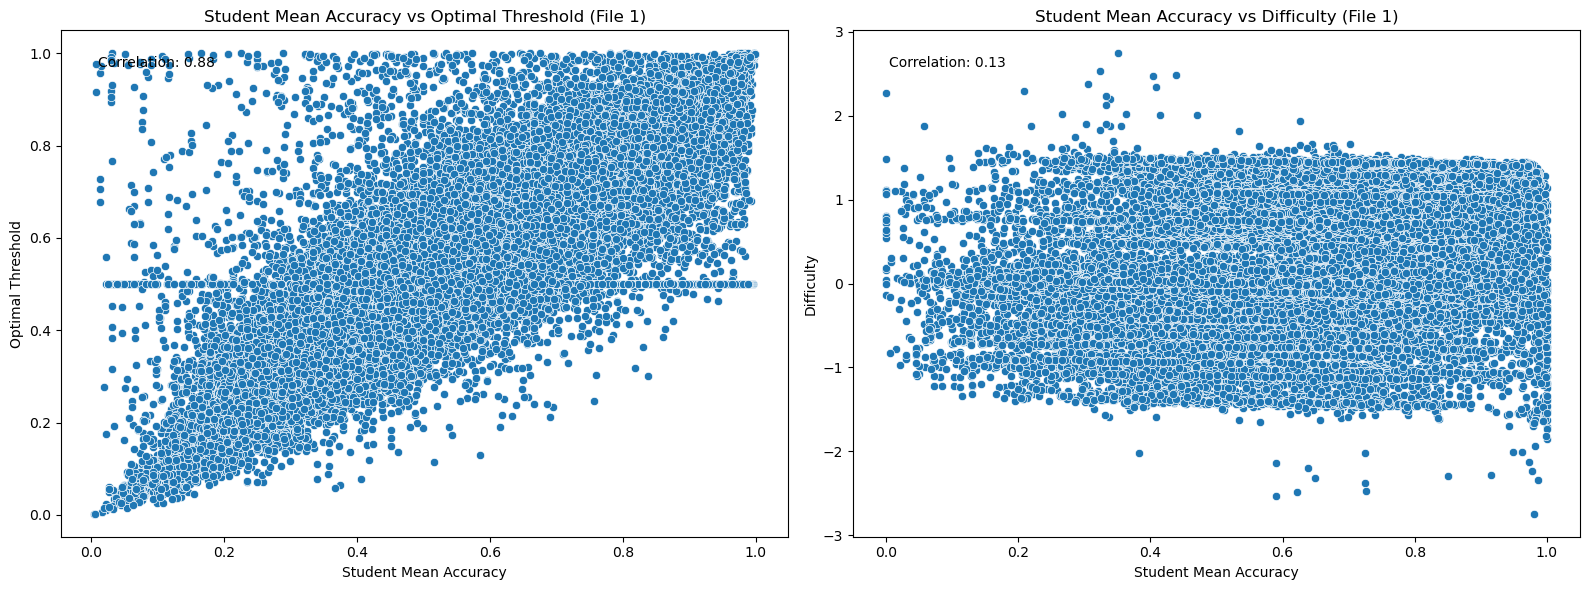


Summary Statistics (File 1):
       student_mean_accuracy  optimal_threshold    difficulty
count          105816.000000       83947.000000  59358.000000
mean                0.607305           0.611824      0.074640
std                 0.220027           0.196493      0.572328
min                 0.000000           0.002409     -2.744580
25%                 0.459459           0.479720     -0.087085
50%                 0.618384           0.617797     -0.014666
75%                 0.773842           0.762030      0.158471
max                 1.000000           0.999999      2.744580

Correlation Matrix (File 1):
                       student_mean_accuracy  optimal_threshold  difficulty
student_mean_accuracy               1.000000           0.878094    0.132280
optimal_threshold                   0.878094           1.000000    0.124154
difficulty                          0.132280           0.124154    1.000000

Number of complete cases (File 1):
student_mean_accuracy vs optimal_threshold

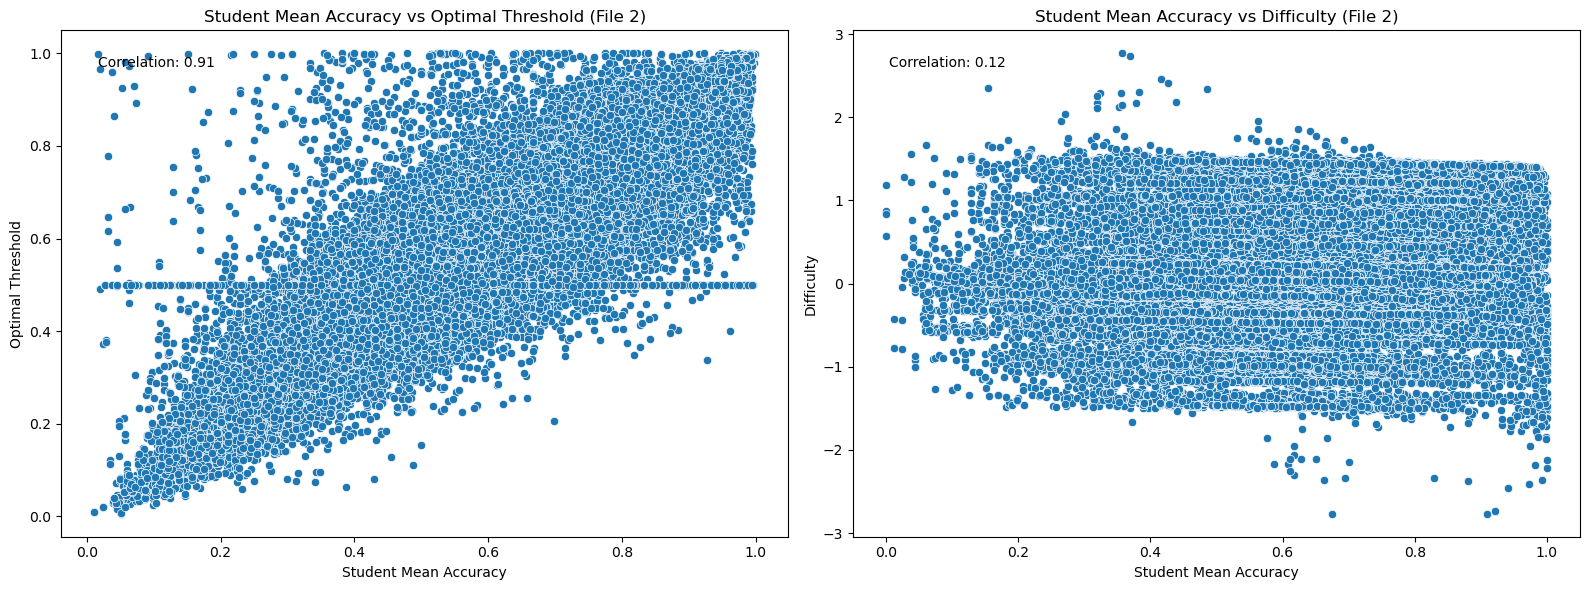


Summary Statistics (File 2):
       student_mean_accuracy  optimal_threshold     difficulty
count          136899.000000      119944.000000  106545.000000
mean                0.624955           0.621427       0.076530
std                 0.200101           0.189627       0.517883
min                 0.000000           0.005726      -2.767581
25%                 0.489426           0.494050      -0.088515
50%                 0.636364           0.627918      -0.015657
75%                 0.775814           0.766514       0.119729
max                 1.000000           1.000000       2.767581

Correlation Matrix (File 2):
                       student_mean_accuracy  optimal_threshold  difficulty
student_mean_accuracy               1.000000           0.905792    0.122747
optimal_threshold                   0.905792           1.000000    0.117754
difficulty                          0.122747           0.117754    1.000000

Number of complete cases (File 2):
student_mean_accuracy vs optimal_

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Function to create correlation plot and calculate statistics
def plot_correlations(df, title_suffix):
    plt.figure(figsize=(16, 6))

    # Prepare data for student_mean_accuracy vs optimal_threshold
    data1 = df[['student_mean_accuracy', 'optimal_threshold']].dropna()

    # Plot 1: student_mean_accuracy vs optimal_threshold
    plt.subplot(1, 2, 1)
    sns.scatterplot(x='student_mean_accuracy', y='optimal_threshold', data=data1)
    plt.title(f'Student Mean Accuracy vs Optimal Threshold ({title_suffix})')
    plt.xlabel('Student Mean Accuracy')
    plt.ylabel('Optimal Threshold')

    # Calculate and display correlation coefficient
    corr_coef1, _ = stats.pearsonr(data1['student_mean_accuracy'], data1['optimal_threshold'])
    plt.text(0.05, 0.95, f'Correlation: {corr_coef1:.2f}', transform=plt.gca().transAxes, 
             verticalalignment='top', fontsize=10)

    # Prepare data for student_mean_accuracy vs difficulty
    data2 = df[['student_mean_accuracy', 'difficulty']].dropna()

    # Plot 2: student_mean_accuracy vs difficulty
    plt.subplot(1, 2, 2)
    sns.scatterplot(x='student_mean_accuracy', y='difficulty', data=data2)
    plt.title(f'Student Mean Accuracy vs Difficulty ({title_suffix})')
    plt.xlabel('Student Mean Accuracy')
    plt.ylabel('Difficulty')

    # Calculate and display correlation coefficient
    corr_coef2, _ = stats.pearsonr(data2['student_mean_accuracy'], data2['difficulty'])
    plt.text(0.05, 0.95, f'Correlation: {corr_coef2:.2f}', transform=plt.gca().transAxes, 
             verticalalignment='top', fontsize=10)

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print(f"\nSummary Statistics ({title_suffix}):")
    print(df[['student_mean_accuracy', 'optimal_threshold', 'difficulty']].describe())

    # Print correlation matrix
    print(f"\nCorrelation Matrix ({title_suffix}):")
    print(df[['student_mean_accuracy', 'optimal_threshold', 'difficulty']].corr())

    # Print number of complete cases for each pair
    print(f"\nNumber of complete cases ({title_suffix}):")
    print(f"student_mean_accuracy vs optimal_threshold: {len(data1)}")
    print(f"student_mean_accuracy vs difficulty: {len(data2)}")

# Create plots and calculate statistics for both dataframes
plot_correlations(df1, "File 1")
plot_correlations(df2, "File 2")

# Calculate and print the differences in correlations
corr1 = df1[['student_mean_accuracy', 'optimal_threshold', 'difficulty']].corr()
corr2 = df2[['student_mean_accuracy', 'optimal_threshold', 'difficulty']].corr()
corr_diff = corr2 - corr1

print("\nDifferences in Correlations (File 2 - File 1):")
print(corr_diff)

In [5]:
#copy to local IP store as main IP file
if False:
    import shutil
    shutil.copy(file2, '../currentItemParameters/')
    print(f"Successfully copied {file2} to ../currentItemParameters/")

Successfully copied model_v50_sigmoidRegressorXGB/ELA_ItemParameters_v5.csv to ../currentItemParameters/


In [7]:
df2.columns

Index(['question_id', 'skill_id', 'discriminability', 'difficulty', 'guessing',
       'inattention', 'discriminability_error', 'difficulty_error',
       'guessing_error', 'inattention_error', 'auc_roc', 'optimal_threshold',
       'tpr', 'tnr', 'skill_optimal_threshold', 'student_mean_accuracy',
       'sample_size', 'date_created', 'version'],
      dtype='object')

In [16]:
# copy to snowflake for curriculum QA table
if False:    
    try:
        import SnowflakeETL
    except:    
        import os, sys
        current_dir = os.getcwd()
        snowflake_path = os.path.join(os.path.dirname(current_dir), 'SnowflakeETL')
        sys.path.append(snowflake_path)
        import SnowflakeETL

    import boto3, os
    s3_client = boto3.client('s3')
    response=s3_client.upload_file(filename,'product-snowflake-testing',filename)
    print('exported to s3 location')
        
    #create snowflake table
    SnowflakeETL.run_snowflake_query("create or replace table product_testing."+tablename+" (question_id TEXT, "+
                         "skill_id TEXT, discriminability FLOAT, difficulty FLOAT, guessing FLOAT, inattention FLOAT, "+
                        "discriminability_error FLOAT, difficulty_error FLOAT, guessing_error FLOAT, "+
                         "inattention_error FLOAT, auc_roc FLOAT, optimal_threshold FLOAT, tpr FLOAT, tnr FLOAT, "+
                         "skill_optimal_threshold FLOAT, student_mean_accuracy FLOAT, " +
                         "sample_size INTEGER, date_created DATETIME, version STRING)")
    print(f'new snowflake table {tablename} created')


    #copy data into sf table
    SnowflakeETL.run_snowflake_query("copy into product_testing."+tablename+" from @public.product_testing_stage/"+filename)
    print('exported to snowflake')


exported to s3 location
new snowflake table ELAITEMPARAMETERESTIMATES20241212 created
exported to snowflake
